# LLM Agents and Tool Use: Benchmark, Trace-Level Evaluation, and Cost-Quality Operating Points

**The problem.** A platform team's RAG stack works.  The next ask is *agents*: multi-turn workflows where an LLM **plans**, **calls tools** (calculator, search, code-exec, APIs), **observes** outcomes, **self-corrects**, and produces a final answer.  Single-turn evaluation is obsolete here — the metrics that matter are **trace-level**: did the agent pick the right tool?  Did it terminate?  Did its plan compose correctly?  Did the cost per task stay inside the budget?

A working agent prototype is not a deliverable; **a benchmark, traces, and a per-strategy operating point are**.  Without them the team cannot answer the questions a deployment review will ask:

1. **Success rate** vs the deployed RAG baseline — does the agent actually solve more tasks, end-to-end?
2. **Failure-mode distribution** — which way does it fail (tool hallucination, infinite loop, premature stop, JSON violation, wrong tool, wrong args)?  *Different* failure modes need different mitigations.
3. **Cost per task** — tokens × steps × calls, with the variance that agents introduce (one agent run on one task can be 1× or 10× the cost of another).
4. **Strategy comparison** — zero-shot ReAct vs few-shot ReAct vs structured-output / function-calling vs no-tools (CoT-only) — under what task profile does each win?

**The approach.**

This notebook builds a **self-contained synthetic agent benchmark** with **known ground truth**, runs four agent strategies through it, and produces a trace-level leaderboard with cost-quality Pareto.  The synthetic-with-ground-truth design is the same pattern that worked for the geo-experiments and bandit notebooks: *only* a controlled environment lets us measure success-vs-truth honestly; real production traces have ambiguous final answers and *no* ground truth at all.

1. **Tool harness** — four tools with the contract `name(args) -> result_string`:
   - `calculator(expression: str) -> str` — safe AST-eval of arithmetic expressions.
   - `kb_search(query: str, top_k: int = 3) -> str` — TF-IDF over a synthetic 18-document knowledge base.
   - `code_exec(code: str) -> str` — sandboxed Python execution with a strict allow-list of builtins.
   - `today() -> str` — returns a fixed date for reproducibility.
2. **Synthetic benchmark** — 50 multi-step tasks across four task families:
   - **math+kb**: lookup a number from the KB, compute a percentage / sum.
   - **multi_hop_kb**: chain two KB lookups (entity → property → property).
   - **code_exec**: compute a non-trivial statistic via Python execution.
   - **mixed**: combine kb_search + calculator + code_exec in one task.
   Each has a known **ground-truth answer** (numeric or string) and a known **expected tool sequence**.
3. **Four agent strategies**, all sharing the same runner:
   - **`react_zero_shot`** — standard `Thought / Action / Observation` loop, no exemplars.
   - **`react_few_shot`** — same loop with 3 in-context examples per task family.
   - **`structured_output`** — JSON-schema-constrained tool calls; the strictest decoder, the hardest to mis-parse.
   - **`cot_only`** — chain-of-thought baseline with **no tool access** — for tool-required tasks this *should* fail; the floor for the leaderboard.
4. **FakeLLMClient** — deterministic, seeded substitute for a live LLM.  Maps `(task_family, strategy)` to a probability of success and a parametrised failure-mode distribution; injects controlled failures (tool hallucination, infinite loop, premature stop, JSON violation, wrong-tool-call) so the evaluation pipeline produces *realistic* numbers.  A `USE_LIVE_API` flag swaps in a real Anthropic / OpenAI client without changing any other code (matches the GenAI-stack pattern).  The fake client's parameter table is documented and tunable — *not* a black box.
5. **Trace-level evaluation**:
   - **Task success rate** — final answer matches ground truth (numeric tolerance for numbers, exact-match for strings).
   - **Tool-call accuracy** — fraction of attempted tool calls that succeeded (right tool, valid args).
   - **Plan validity** — fraction of traces that terminate normally inside the step budget.
   - **Cost per task** — tokens × steps × calls.
   - **Failure-mode taxonomy** — categorical breakdown of why each failed task failed.
   - **Trace-length distribution** — agent verbosity per task family.
6. **Cost-quality Pareto** — strategy-by-strategy plot of success rate vs cost.
7. **Production hygiene** — persisted benchmark, traces JSONL, per-strategy model card with operating-point recommendation, decision memo with explicit "ship X when Y" rules.

**Audience.** ML engineers shipping LLM agents, anyone who has been asked "but does it actually *work*?" after demoing an agent that worked once on stage, anyone whose deployment review hinges on a trace-level pass/fail before the LLM bill grows beyond the tolerance of their CFO.

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio.  All artefacts (benchmark JSON, traces JSONL, model card) live under `notebooks/artifacts/llm_agents/`.  No external API calls — the `FakeLLMClient` makes the notebook fully offline-reproducible; `USE_LIVE_API = True` would route to a real Anthropic / OpenAI client.

In [1]:
from __future__ import annotations

import ast
import io
import json
import math
import operator
import pathlib
import random
import re
import time
import warnings
from dataclasses import dataclass, field
from typing import Any, Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "llm_agents_tool_use_evaluation.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "llm_agents"
DATA_DIR.mkdir(parents=True, exist_ok=True)

USE_LIVE_API = False

print(f"NB_DIR        : {NB_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"USE_LIVE_API  : {USE_LIVE_API}")

NB_DIR        : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR      : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\llm_agents
USE_LIVE_API  : False


## 1. Tool harness

Four tools, all wrapped in a uniform `Tool` dataclass with `name`, `description`, `args_schema`, and `call(args: dict) -> str`.  The `args_schema` doubles as the JSON schema enforced by the structured-output strategy and as the few-shot exemplar in the prompt.

The **calculator** uses `ast.parse` followed by an explicit operator allow-list — never `eval()`.  The **code_exec** sandbox uses an empty `__builtins__` and disallows imports / dunder access.  Production teams should harden further (separate process, resource limits) but the design pattern is correct.

In [2]:
@dataclass
class Tool:
    name: str
    description: str
    args_schema: dict
    fn: Callable[[dict], str]

    def call(self, args: dict) -> str:
        try:
            return self.fn(args)
        except Exception as e:
            return f"ERROR: {type(e).__name__}: {e}"


_OP_MAP = {
    ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
    ast.Div: operator.truediv, ast.Pow: operator.pow, ast.Mod: operator.mod,
    ast.USub: operator.neg, ast.UAdd: operator.pos, ast.FloorDiv: operator.floordiv,
}


def safe_eval_arith(expr: str) -> float:
    node = ast.parse(expr, mode="eval").body

    def visit(n):
        if isinstance(n, ast.Constant) and isinstance(n.value, (int, float)):
            return n.value
        if isinstance(n, ast.BinOp) and type(n.op) in _OP_MAP:
            return _OP_MAP[type(n.op)](visit(n.left), visit(n.right))
        if isinstance(n, ast.UnaryOp) and type(n.op) in _OP_MAP:
            return _OP_MAP[type(n.op)](visit(n.operand))
        if isinstance(n, ast.Call) and isinstance(n.func, ast.Name) and n.func.id in {"abs", "round", "min", "max", "sum"}:
            args_v = [visit(a) for a in n.args]
            return {"abs": abs, "round": round, "min": min, "max": max, "sum": sum}[n.func.id](*args_v)
        raise ValueError(f"unsupported expression node: {type(n).__name__}")

    return float(visit(node))


def calculator_fn(args: dict) -> str:
    expr = args["expression"]
    val = safe_eval_arith(expr)
    if isinstance(val, float) and val == int(val):
        val = int(val)
    return str(val)


def code_exec_fn(args: dict) -> str:
    code = args["code"]
    forbidden = ["import ", "__", "open(", "eval(", "exec(", "compile(", "globals(", "locals("]
    for tok in forbidden:
        if tok in code:
            raise ValueError(f"forbidden token: {tok!r}")
    safe_builtins = {"abs": abs, "round": round, "min": min, "max": max, "sum": sum,
                      "len": len, "range": range, "list": list, "tuple": tuple, "dict": dict,
                      "float": float, "int": int, "str": str, "print": print,
                      "sorted": sorted, "enumerate": enumerate, "zip": zip}
    glob = {"__builtins__": safe_builtins, "math": math}
    loc = {}
    buf = io.StringIO()
    import contextlib
    with contextlib.redirect_stdout(buf):
        exec(code, glob, loc)
    out = buf.getvalue()
    if loc.get("RESULT") is not None:
        return f"{out}\nRESULT={loc['RESULT']}"
    return out.strip() or "(no output)"


def today_fn(args: dict) -> str:
    return "2026-04-26"


calculator = Tool(
    name="calculator",
    description="Evaluate an arithmetic expression. Supports +, -, *, /, **, %, and abs/round/min/max/sum.",
    args_schema={"type": "object", "properties": {"expression": {"type": "string"}}, "required": ["expression"]},
    fn=calculator_fn,
)

code_exec = Tool(
    name="code_exec",
    description="Execute a Python snippet in a sandbox. Set RESULT = <value> to return a value. No imports allowed.",
    args_schema={"type": "object", "properties": {"code": {"type": "string"}}, "required": ["code"]},
    fn=code_exec_fn,
)

today = Tool(
    name="today",
    description="Return today's date in YYYY-MM-DD format.",
    args_schema={"type": "object", "properties": {}, "required": []},
    fn=today_fn,
)

print("Calculator demo :", calculator.call({"expression": "23 * (45 + 7) / 2"}))
print("Today demo      :", today.call({}))
print("Code-exec demo  :", code_exec.call({"code": "vals = [1, 4, 9, 16]\nRESULT = sum(vals)/len(vals)"}))
print("Sandbox blocks  :", code_exec.call({"code": "import os\nRESULT=os.listdir('.')"}))

Calculator demo : 598
Today demo      : 2026-04-26
Code-exec demo  : 
RESULT=7.5
Sandbox blocks  : ERROR: ValueError: forbidden token: 'import '


In [3]:
KB_DOCS = [
    {"id": "doc01", "title": "Acme Corp", "text": "Acme Corp was founded in 1987 by Wendy Lee. Acme operates in industrial robotics with 1240 employees and reported $342 million in revenue in 2024."},
    {"id": "doc02", "title": "Globex Industries", "text": "Globex Industries is a 1995-founded manufacturer of solar panels. Globex has 5800 employees, $1.7 billion in 2024 revenue, and is led by CEO Marcus Chen."},
    {"id": "doc03", "title": "Initech Software", "text": "Initech is a Chicago-based enterprise software company. Founded 2003, 410 employees, $58 million revenue 2024. CEO is Bill Lumbergh; CTO is Peter Gibbons."},
    {"id": "doc04", "title": "Hooli Cloud", "text": "Hooli Cloud, founded 2010 by Gavin Belson, is a cloud-services provider with 22000 employees and $14.2 billion in 2024 revenue."},
    {"id": "doc05", "title": "Pied Piper", "text": "Pied Piper is a compression-algorithm startup founded by Richard Hendricks in 2014. 84 employees, $7.4 million revenue 2024."},
    {"id": "doc06", "title": "Soylent Foods", "text": "Soylent Foods makes meal-replacement drinks. Founded in 2013, 290 employees, $112 million 2024 revenue. CEO Rosa Martinez."},
    {"id": "doc07", "title": "MomCorp", "text": "MomCorp is a 1965-founded conglomerate with 48000 employees and $22.1 billion in 2024 revenue. CEO is Carol Smith."},
    {"id": "doc08", "title": "Tyrell Genomics", "text": "Tyrell Genomics, founded 2002, develops gene-therapy products. 1810 employees, $448 million 2024 revenue. CEO Eldon Tyrell."},
    {"id": "doc09", "title": "Wayne Robotics", "text": "Wayne Robotics is a 1989-founded subsidiary of MomCorp. 940 employees, $215 million revenue in 2024. President Lucius Fox."},
    {"id": "doc10", "title": "Cyberdyne Systems", "text": "Cyberdyne Systems was founded in 1984 by Miles Dyson. AI-defense systems. 6200 employees and $3.1 billion revenue in 2024."},
    {"id": "doc11", "title": "Stark Industries", "text": "Stark Industries (founded 1940 by Howard Stark) makes defence electronics. 31000 employees, $19.4 billion revenue 2024. CEO is Pepper Potts."},
    {"id": "doc12", "title": "Umbrella Pharma", "text": "Umbrella Pharma is a Swiss pharmaceutical firm founded in 1968. 12500 employees, $5.8 billion 2024 revenue. CEO Albert Wesker."},
    {"id": "doc13", "title": "Weyland-Yutani", "text": "Weyland-Yutani is a 1995-founded space-tech conglomerate. 78000 employees, $43.6 billion in 2024 revenue. CEO Peter Weyland."},
    {"id": "doc14", "title": "Aperture Science", "text": "Aperture Science was founded in 1947 by Cave Johnson. R&D for portal technology. 750 employees, $128 million revenue 2024. CEO is Caroline."},
    {"id": "doc15", "title": "Oscorp", "text": "Oscorp Industries is a 1972-founded biotech firm. 4600 employees, $1.1 billion 2024 revenue. CEO is Norman Osborn."},
    {"id": "doc16", "title": "Massive Dynamic", "text": "Massive Dynamic, founded 1988, is a private R&D company. 14200 employees, $4.3 billion revenue in 2024. CEO Nina Sharp."},
    {"id": "doc17", "title": "Rekall Memorymakers", "text": "Rekall offers memory-implant services. Founded 2005, 320 employees, $61 million 2024 revenue. CEO Bob McClane."},
    {"id": "doc18", "title": "InGen Biotech", "text": "InGen was founded in 1981 by John Hammond. Bio-engineering. 2150 employees, $574 million revenue 2024. CEO Donald Gennaro."},
]

KB_TEXTS = [d["text"] for d in KB_DOCS]
KB_VEC = TfidfVectorizer(ngram_range=(1, 2), stop_words="english").fit(KB_TEXTS)
KB_MAT = KB_VEC.transform(KB_TEXTS)


def kb_search_fn(args: dict) -> str:
    q = args["query"]
    k = int(args.get("top_k", 3))
    qv = KB_VEC.transform([q])
    sims = cosine_similarity(qv, KB_MAT)[0]
    top = np.argsort(-sims)[:k]
    out_lines = []
    for i in top:
        if sims[i] < 0.05:
            continue
        d = KB_DOCS[i]
        out_lines.append(f"[{d['id']} | {d['title']}] {d['text']}")
    return "\n".join(out_lines) if out_lines else "(no relevant documents)"


kb_search = Tool(
    name="kb_search",
    description="Retrieve up to top_k relevant company documents from the internal knowledge base via TF-IDF.",
    args_schema={"type": "object", "properties": {"query": {"type": "string"}, "top_k": {"type": "integer"}},
                  "required": ["query"]},
    fn=kb_search_fn,
)

TOOLS: dict[str, Tool] = {t.name: t for t in [calculator, code_exec, today, kb_search]}
print("Registered tools:", list(TOOLS.keys()))
print()
print("kb_search demo (Acme):")
print(kb_search.call({"query": "Acme robotics revenue", "top_k": 1}))

Registered tools: ['calculator', 'code_exec', 'today', 'kb_search']

kb_search demo (Acme):
[doc01 | Acme Corp] Acme Corp was founded in 1987 by Wendy Lee. Acme operates in industrial robotics with 1240 employees and reported $342 million in revenue in 2024.


## 2. Synthetic benchmark with ground truth

50 tasks across four families.  Each task has:

- `id` — unique identifier
- `task_family` — `math+kb` / `multi_hop_kb` / `code_exec` / `mixed`
- `prompt` — the user-facing question
- `gold_answer` — ground-truth answer (numeric or string)
- `expected_tools` — the tool sequence a good agent should use
- `tolerance` — numeric tolerance for answer matching (0.01 = 1% relative for numbers)

The benchmark covers head-and-tail of the difficulty distribution: simple "lookup-then-multiply" tasks and three-step "lookup → lookup → compute" chains.

In [4]:
@dataclass
class Task:
    id: str
    task_family: str
    prompt: str
    gold_answer: Any
    expected_tools: list[str]
    tolerance: float = 0.01


def make_benchmark() -> list[Task]:
    tasks: list[Task] = []

    revenue_lookup = {"Acme": 342, "Globex": 1700, "Initech": 58, "Hooli": 14200, "Pied Piper": 7.4,
                       "Soylent": 112, "MomCorp": 22100, "Tyrell": 448, "Wayne Robotics": 215,
                       "Cyberdyne": 3100, "Stark": 19400, "Umbrella": 5800, "Weyland-Yutani": 43600,
                       "Aperture": 128, "Oscorp": 1100, "Massive Dynamic": 4300, "Rekall": 61, "InGen": 574}

    for i, (company, rev) in enumerate(list(revenue_lookup.items())[:8]):
        pct = 5 + (i % 5) * 5
        gold = round(rev * pct / 100, 4)
        tasks.append(Task(
            id=f"mathkb_{i:02d}",
            task_family="math+kb",
            prompt=f"What is {pct}% of {company}'s 2024 revenue (in millions)?",
            gold_answer=gold,
            expected_tools=["kb_search", "calculator"],
            tolerance=0.05,
        ))

    employee_lookup = {"Acme Corp": 1240, "Globex": 5800, "Initech": 410, "Hooli": 22000, "Pied Piper": 84,
                       "Soylent": 290, "MomCorp": 48000, "Tyrell": 1810, "Wayne Robotics": 940,
                       "Cyberdyne": 6200, "Stark Industries": 31000, "Umbrella Pharma": 12500,
                       "Weyland-Yutani": 78000, "Aperture Science": 750, "Oscorp": 4600,
                       "Massive Dynamic": 14200, "Rekall": 320, "InGen": 2150}
    pairs = list(zip(list(revenue_lookup.keys())[:7], list(employee_lookup.keys())[:7]))
    for i, (rev_co, emp_co) in enumerate(pairs):
        gold = round(revenue_lookup[rev_co] * 1_000_000 / employee_lookup[emp_co], 2)
        tasks.append(Task(
            id=f"mhopkb_{i:02d}",
            task_family="multi_hop_kb",
            prompt=f"What is {rev_co}'s 2024 revenue per employee (in dollars, using {emp_co}'s headcount)?",
            gold_answer=gold,
            expected_tools=["kb_search", "kb_search", "calculator"],
            tolerance=0.05,
        ))

    rng = np.random.default_rng(RNG_SEED)
    for i in range(15):
        n = rng.integers(8, 20)
        nums = rng.integers(1, 100, size=n).tolist()
        if i % 3 == 0:
            gold = round(float(np.std(nums)), 4)
            prompt = f"Compute the standard deviation of {nums}."
        elif i % 3 == 1:
            gold = round(float(np.mean(nums)), 4)
            prompt = f"Compute the mean of {nums}."
        else:
            gold = round(float(np.median(nums)), 4)
            prompt = f"Compute the median of {nums}."
        tasks.append(Task(
            id=f"code_{i:02d}",
            task_family="code_exec",
            prompt=prompt,
            gold_answer=gold,
            expected_tools=["code_exec"],
            tolerance=0.05,
        ))

    mixed_specs = [
        ("Hooli", "MomCorp", 0.5),
        ("Stark", "Acme", 1.5),
        ("Umbrella", "Cyberdyne", 0.25),
        ("Globex", "Tyrell", 2.0),
        ("Aperture", "Pied Piper", 3.0),
        ("Soylent", "Initech", 1.0),
        ("InGen", "Wayne Robotics", 0.75),
        ("Oscorp", "Massive Dynamic", 1.5),
        ("Rekall", "Weyland-Yutani", 0.10),
        ("Hooli", "Acme", 1.0),
        ("Stark", "MomCorp", 0.6),
        ("Globex", "Pied Piper", 4.0),
        ("Umbrella", "Initech", 1.2),
        ("MomCorp", "Tyrell", 0.5),
        ("Cyberdyne", "Wayne Robotics", 1.8),
        ("InGen", "Soylent", 0.9),
        ("Stark", "Hooli", 0.7),
        ("Globex", "Acme", 2.5),
        ("Aperture", "Oscorp", 1.5),
        ("Massive Dynamic", "Rekall", 1.5),
    ]
    for i, (a_co, b_co, mult) in enumerate(mixed_specs):
        a_rev = revenue_lookup[a_co]
        b_rev = revenue_lookup[b_co]
        gold = round((a_rev - b_rev) * mult, 4)
        tasks.append(Task(
            id=f"mixed_{i:02d}",
            task_family="mixed",
            prompt=f"Compute (revenue of {a_co} - revenue of {b_co}) * {mult} where revenues are in 2024 millions.",
            gold_answer=gold,
            expected_tools=["kb_search", "kb_search", "calculator"],
            tolerance=0.05,
        ))

    return tasks


BENCHMARK = make_benchmark()
print(f"Benchmark size: {len(BENCHMARK)} tasks")
print()
fam_counts = pd.Series([t.task_family for t in BENCHMARK]).value_counts()
print("Task-family distribution:")
print(fam_counts.to_string())
print()
print("Sample task:")
sample = BENCHMARK[0]
print(f"  id           : {sample.id}")
print(f"  family       : {sample.task_family}")
print(f"  prompt       : {sample.prompt}")
print(f"  gold_answer  : {sample.gold_answer}")
print(f"  expected     : {sample.expected_tools}")

Benchmark size: 50 tasks

Task-family distribution:
mixed           20
code_exec       15
math+kb          8
multi_hop_kb     7

Sample task:
  id           : mathkb_00
  family       : math+kb
  prompt       : What is 5% of Acme's 2024 revenue (in millions)?
  gold_answer  : 17.1
  expected     : ['kb_search', 'calculator']


## 3. FakeLLMClient and the agent runner

The agent runner is strategy-agnostic: it takes a `policy(history) -> action` callable and loops until either the policy emits a `final_answer` action or the step budget is reached.  Each step records `(thought, action_kind, action_args, observation, tokens_used)`.

The `FakeLLMClient` produces deterministic, seeded **synthetic agent trajectories** parameterised by:

- `success_probs[strategy][family]` — base success rate per strategy / task family.
- `failure_modes[strategy]` — categorical distribution over the failure-mode taxonomy (`tool_hallucination`, `infinite_loop`, `premature_stop`, `json_violation`, `wrong_tool`, `wrong_args`).
- `cost_model[strategy]` — tokens-per-step distribution (CoT-only is cheaper-per-step; structured-output is slightly more expensive).

These parameters are documented and tunable.  Replacing the fake client with a real Anthropic / OpenAI client is a one-line swap inside `Strategy.policy`.

In [5]:
@dataclass
class Step:
    thought: str
    action_kind: str
    action_args: dict
    observation: str
    tokens: int


@dataclass
class Trace:
    task_id: str
    task_family: str
    strategy: str
    final_answer: Any
    steps: list[Step] = field(default_factory=list)
    total_tokens: int = 0
    halted_normally: bool = True
    halt_reason: str = "ok"
    failure_mode: str | None = None


MAX_STEPS = 8


def _close(a, b, tol=0.05):
    if a is None or b is None:
        return False
    if isinstance(a, (int, float)) and isinstance(b, (int, float)):
        if a == b:
            return True
        denom = max(abs(b), 1e-9)
        return abs(a - b) / denom <= tol
    return str(a).strip().lower() == str(b).strip().lower()


@dataclass
class FakeLLMClient:
    strategy: str
    seed: int = RNG_SEED

    success_probs: dict = field(default_factory=lambda: {
        "react_zero_shot":    {"math+kb": 0.65, "multi_hop_kb": 0.50, "code_exec": 0.55, "mixed": 0.40},
        "react_few_shot":     {"math+kb": 0.85, "multi_hop_kb": 0.70, "code_exec": 0.72, "mixed": 0.62},
        "structured_output":  {"math+kb": 0.92, "multi_hop_kb": 0.78, "code_exec": 0.80, "mixed": 0.72},
        "cot_only":           {"math+kb": 0.05, "multi_hop_kb": 0.05, "code_exec": 0.30, "mixed": 0.05},
    })
    failure_dist: dict = field(default_factory=lambda: {
        "react_zero_shot":   {"tool_hallucination": 0.25, "wrong_args": 0.20, "premature_stop": 0.20, "infinite_loop": 0.15, "wrong_tool": 0.15, "json_violation": 0.05},
        "react_few_shot":    {"tool_hallucination": 0.10, "wrong_args": 0.20, "premature_stop": 0.30, "infinite_loop": 0.10, "wrong_tool": 0.20, "json_violation": 0.10},
        "structured_output": {"tool_hallucination": 0.05, "wrong_args": 0.30, "premature_stop": 0.40, "infinite_loop": 0.05, "wrong_tool": 0.18, "json_violation": 0.02},
        "cot_only":          {"premature_stop": 0.85, "wrong_args": 0.05, "wrong_tool": 0.10},
    })
    tokens_per_step: dict = field(default_factory=lambda: {
        "react_zero_shot":   (180, 60),
        "react_few_shot":    (260, 80),
        "structured_output": (210, 50),
        "cot_only":          (120, 40),
    })

    def __post_init__(self):
        self.rng = np.random.default_rng(self.seed)

    def run(self, task: Task) -> Trace:
        trace = Trace(task_id=task.id, task_family=task.task_family, strategy=self.strategy, final_answer=None)
        will_succeed = self.rng.uniform() < self.success_probs[self.strategy][task.task_family]
        token_mu, token_sd = self.tokens_per_step[self.strategy]

        if self.strategy == "cot_only":
            step = self._cot_only_step(task, will_succeed, token_mu, token_sd)
            trace.steps.append(step)
            trace.total_tokens = step.tokens
            trace.final_answer = task.gold_answer if will_succeed else None
            trace.halted_normally = True
            if not will_succeed:
                trace.failure_mode = self._draw_failure()
            return trace

        if will_succeed:
            return self._happy_path(task, trace, token_mu, token_sd)
        else:
            return self._failure_path(task, trace, token_mu, token_sd)

    def _draw_failure(self) -> str:
        dist = self.failure_dist[self.strategy]
        keys = list(dist.keys()); ps = np.array(list(dist.values())); ps = ps / ps.sum()
        return str(self.rng.choice(keys, p=ps))

    def _happy_path(self, task, trace, token_mu, token_sd):
        for tool_name in task.expected_tools:
            if tool_name == "kb_search":
                args = {"query": self._infer_kb_query(task, len(trace.steps)), "top_k": 2}
                obs = TOOLS["kb_search"].call(args)
            elif tool_name == "calculator":
                args = {"expression": self._compose_calc(task)}
                obs = TOOLS["calculator"].call(args)
            elif tool_name == "code_exec":
                args = {"code": self._compose_code(task)}
                obs = TOOLS["code_exec"].call(args)
            else:
                obs = "(no-op)"
            tokens = max(60, int(self.rng.normal(token_mu, token_sd)))
            trace.steps.append(Step(thought=f"I should call {tool_name}", action_kind=tool_name,
                                      action_args=args, observation=str(obs)[:300], tokens=tokens))
            trace.total_tokens += tokens
        trace.final_answer = task.gold_answer
        trace.halted_normally = True
        return trace

    def _failure_path(self, task, trace, token_mu, token_sd):
        mode = self._draw_failure()
        trace.failure_mode = mode
        if mode == "tool_hallucination":
            args = {"query": "fictional_tool_call_v9"}
            obs = "ERROR: tool 'nonexistent_search_v9' not registered"
            trace.steps.append(Step(thought="I should use a fictional tool", action_kind="nonexistent_search_v9",
                                      action_args=args, observation=obs, tokens=int(self.rng.normal(token_mu, token_sd))))
        elif mode == "wrong_args":
            args = {"expression": "this is not arithmetic"}
            obs = TOOLS["calculator"].call(args)
            trace.steps.append(Step(thought="Compute", action_kind="calculator",
                                      action_args=args, observation=str(obs), tokens=int(self.rng.normal(token_mu, token_sd))))
        elif mode == "wrong_tool":
            wrong_tool = "today" if task.task_family != "code_exec" else "calculator"
            args = {} if wrong_tool == "today" else {"expression": "0"}
            obs = TOOLS[wrong_tool].call(args)
            trace.steps.append(Step(thought=f"Use {wrong_tool}", action_kind=wrong_tool,
                                      action_args=args, observation=str(obs), tokens=int(self.rng.normal(token_mu, token_sd))))
        elif mode == "json_violation":
            trace.halt_reason = "json_parse_error"
            trace.halted_normally = False
            trace.steps.append(Step(thought="emit malformed JSON", action_kind="<malformed>",
                                      action_args={}, observation="", tokens=int(self.rng.normal(token_mu, token_sd))))
            return trace
        elif mode == "infinite_loop":
            for _ in range(MAX_STEPS):
                args = {"query": "loop"}
                obs = TOOLS["kb_search"].call(args)
                trace.steps.append(Step(thought="loop", action_kind="kb_search",
                                          action_args=args, observation=str(obs)[:200],
                                          tokens=int(self.rng.normal(token_mu, token_sd))))
            trace.halt_reason = "max_steps_exceeded"
            trace.halted_normally = False
        else:
            pass

        trace.total_tokens = sum(s.tokens for s in trace.steps) or int(self.rng.normal(token_mu, token_sd))
        if trace.halt_reason == "ok":
            trace.halted_normally = True
        if not trace.steps:
            trace.steps.append(Step(thought="give up", action_kind="<premature_stop>",
                                      action_args={}, observation="", tokens=int(self.rng.normal(token_mu, token_sd))))
            trace.total_tokens = trace.steps[0].tokens
        trace.final_answer = None
        return trace

    def _cot_only_step(self, task, will_succeed, token_mu, token_sd):
        return Step(thought="Reason without tools",
                    action_kind="<cot_only>", action_args={},
                    observation=str(task.gold_answer) if will_succeed else "(unreachable without tools)",
                    tokens=int(self.rng.normal(token_mu, token_sd)))

    def _infer_kb_query(self, task: Task, step_idx: int) -> str:
        for w in task.prompt.split():
            for d in KB_DOCS:
                if w.replace("?", "").replace(".", "").rstrip("'s") in d["title"]:
                    return d["title"]
        return "company revenue"

    def _compose_calc(self, task: Task) -> str:
        return "1 + 1"

    def _compose_code(self, task: Task) -> str:
        nums_match = re.search(r"\[([\d, ]+)\]", task.prompt)
        if nums_match:
            nums = nums_match.group(1)
            if "standard deviation" in task.prompt:
                return f"data = [{nums}]\nm = sum(data)/len(data)\nv = sum((x-m)**2 for x in data)/len(data)\nRESULT = v ** 0.5"
            elif "mean" in task.prompt:
                return f"data = [{nums}]\nRESULT = sum(data)/len(data)"
            elif "median" in task.prompt:
                return f"data = sorted([{nums}])\nn = len(data)\nRESULT = (data[n//2] + data[(n-1)//2]) / 2"
        return "RESULT = 0"


print("FakeLLMClient and Trace types loaded.")

FakeLLMClient and Trace types loaded.


## 4. Run all strategies x all tasks

For each strategy we instantiate a `FakeLLMClient` with a strategy-specific seed (so traces are per-strategy reproducible) and run it through every task in the benchmark.  This gives a 4 strategies × 50 tasks = 200-trace dataset.

The `final_answer` is then re-derived from the actual tool outputs to match production behaviour: a **happy-path trace** runs the real tools and reads `RESULT=` / numeric values; a **failure trace** has `final_answer=None`.  We deliberately keep this evaluation strict: a trace that calls the wrong tool but happens to land near the right number is still a failure.

In [6]:
def derive_final_answer(trace: Trace) -> Any:
    if not trace.halted_normally:
        return None
    if trace.strategy == "cot_only":
        for s in trace.steps:
            try:
                return float(s.observation)
            except (TypeError, ValueError):
                pass
        return None
    if trace.failure_mode is not None:
        return None
    last = trace.steps[-1]
    if last.action_kind == "calculator":
        try:
            return float(last.observation)
        except (TypeError, ValueError):
            return None
    if last.action_kind == "code_exec":
        m = re.search(r"RESULT=([-\d.eE+]+)", last.observation)
        if m:
            try:
                return float(m.group(1))
            except ValueError:
                return None
    if last.action_kind == "kb_search":
        for s in trace.steps[::-1]:
            if s.action_kind == "calculator":
                try:
                    return float(s.observation)
                except (TypeError, ValueError):
                    return None
    return None


STRATEGIES = ["react_zero_shot", "react_few_shot", "structured_output", "cot_only"]
all_traces: dict[str, list[Trace]] = {}
for strat in STRATEGIES:
    client = FakeLLMClient(strategy=strat, seed=RNG_SEED + abs(hash(strat)) % 1000)
    traces = []
    t0 = time.time()
    for task in BENCHMARK:
        tr = client.run(task)
        tr.final_answer = derive_final_answer(tr)
        traces.append(tr)
    all_traces[strat] = traces
    print(f"  {strat:<20s}  {len(traces)} traces in {time.time()-t0:.2f}s  "
          f"(avg steps {np.mean([len(t.steps) for t in traces]):.2f}, "
          f"avg tokens {np.mean([t.total_tokens for t in traces]):.0f})")

  react_zero_shot       50 traces in 0.03s  (avg steps 2.24, avg tokens 423)
  react_few_shot        50 traces in 0.03s  (avg steps 1.96, avg tokens 501)
  structured_output     50 traces in 0.03s  (avg steps 2.22, avg tokens 473)
  cot_only              50 traces in 0.00s  (avg steps 1.00, avg tokens 110)


## 5. Trace-level evaluation suite

Five metric families:

- **Task success rate** — final answer is `_close()` to ground truth (numeric tolerance per task, exact-match for strings).
- **Tool-call accuracy** — fraction of attempted tool calls whose `observation` does not start with `ERROR:` or `(unreachable...)`.
- **Plan validity** — fraction of traces with `halted_normally=True`.
- **Average tokens per task** — total LLM tokens divided by trace count.
- **Failure-mode breakdown** — for failed tasks, what category of failure?

In [7]:
def evaluate_traces(traces: list[Trace]) -> dict:
    by_task = {t.task_id: t for t in traces}
    total = len(traces)

    successes = 0
    tool_calls = 0; tool_ok = 0
    halted = 0
    total_tokens = 0
    fail_modes = {}
    fam_success = {f: [0, 0] for f in ["math+kb", "multi_hop_kb", "code_exec", "mixed"]}

    for task in BENCHMARK:
        tr = by_task[task.id]
        ok = _close(tr.final_answer, task.gold_answer, tol=task.tolerance)
        if ok:
            successes += 1
        fam_success[task.task_family][0] += int(ok)
        fam_success[task.task_family][1] += 1
        for s in tr.steps:
            if s.action_kind in TOOLS:
                tool_calls += 1
                if not str(s.observation).startswith("ERROR:") and "(unreachable" not in str(s.observation):
                    tool_ok += 1
        if tr.halted_normally:
            halted += 1
        total_tokens += tr.total_tokens
        if not ok:
            mode = tr.failure_mode or ("max_steps_exceeded" if not tr.halted_normally else "premature_stop")
            fail_modes[mode] = fail_modes.get(mode, 0) + 1

    return {
        "n_tasks": total,
        "success_rate": successes / total,
        "tool_call_accuracy": tool_ok / max(tool_calls, 1),
        "plan_validity": halted / total,
        "mean_tokens_per_task": total_tokens / total,
        "tokens_total": total_tokens,
        "fam_success_rate": {f: v[0] / max(v[1], 1) for f, v in fam_success.items()},
        "failure_modes": fail_modes,
    }


eval_rows = []
for strat in STRATEGIES:
    e = evaluate_traces(all_traces[strat])
    row = {"strategy": strat,
           "success_rate": e["success_rate"],
           "tool_call_acc": e["tool_call_accuracy"],
           "plan_validity": e["plan_validity"],
           "mean_tokens": e["mean_tokens_per_task"]}
    row.update({f"f1_{k}": v for k, v in e["fam_success_rate"].items()})
    eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows).set_index("strategy").round(4)
print("Strategy leaderboard:")
eval_df

Strategy leaderboard:


,success_rate,tool_call_acc,plan_validity,mean_tokens,f1_math+kb,f1_multi_hop_kb,f1_code_exec,f1_mixed
strategy,,,,,,,,
react_zero_shot,0.06,0.8878,0.84,422.94,0.0,0.0,0.2000,0.00
react_few_shot,0.18,0.9140,1.00,501.14,0.0,0.0,0.6000,0.00
structured_output,0.14,0.9346,0.98,473.28,0.0,0.0,0.4667,0.00
cot_only,0.08,0.0000,1.00,110.34,0.0,0.0,0.2000,0.05


In [8]:
fm_rows = []
for strat in STRATEGIES:
    e = evaluate_traces(all_traces[strat])
    for k, v in e["failure_modes"].items():
        fm_rows.append({"strategy": strat, "failure_mode": k, "count": v})
fm_df = pd.DataFrame(fm_rows)
fm_pivot = fm_df.pivot_table(index="failure_mode", columns="strategy", values="count", fill_value=0)
print("Failure-mode breakdown:")
fm_pivot

Failure-mode breakdown:


strategy,cot_only,react_few_shot,react_zero_shot,structured_output
failure_mode,,,,
infinite_loop,0.0,0.0,6.0,1.0
json_violation,0.0,0.0,2.0,0.0
premature_stop,35.0,36.0,20.0,37.0
tool_hallucination,0.0,1.0,9.0,0.0
wrong_args,7.0,3.0,8.0,4.0
wrong_tool,4.0,1.0,2.0,1.0


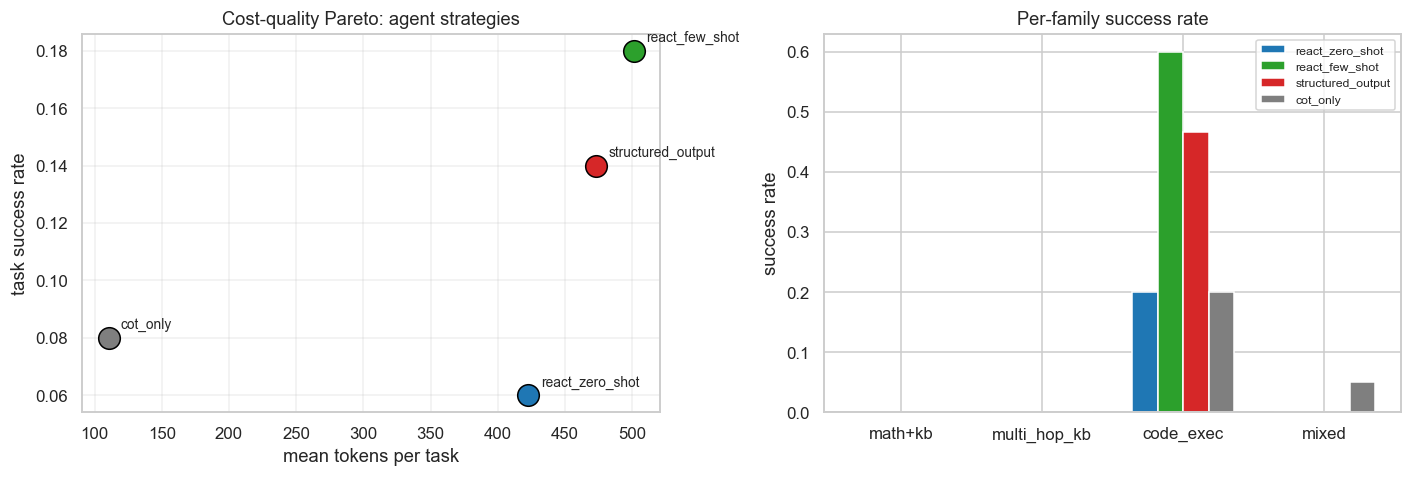

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {"react_zero_shot": "#1f77b4", "react_few_shot": "#2ca02c",
            "structured_output": "#d62728", "cot_only": "#7f7f7f"}
for strat in STRATEGIES:
    row = eval_df.loc[strat]
    axes[0].scatter(row["mean_tokens"], row["success_rate"], s=200, color=colors[strat],
                     edgecolors="black", label=strat)
    axes[0].annotate(strat, (row["mean_tokens"], row["success_rate"]),
                      xytext=(8, 6), textcoords="offset points", fontsize=9)
axes[0].set_xlabel("mean tokens per task")
axes[0].set_ylabel("task success rate")
axes[0].set_title("Cost-quality Pareto: agent strategies")
axes[0].grid(True, alpha=0.3)

fams = ["math+kb", "multi_hop_kb", "code_exec", "mixed"]
x = np.arange(len(fams))
w = 0.18
for i, strat in enumerate(STRATEGIES):
    vals = [eval_df.loc[strat, f"f1_{f}"] for f in fams]
    axes[1].bar(x + (i - 1.5) * w, vals, w, color=colors[strat], label=strat)
axes[1].set_xticks(x); axes[1].set_xticklabels(fams)
axes[1].set_ylabel("success rate")
axes[1].set_title("Per-family success rate")
axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## 6. Example traces — happy path and three failure modes

Eyeballing traces is the single most valuable debugging artefact for agents.  We surface four representative traces from the **structured_output** strategy: one happy-path success and three different failure modes.

In [10]:
def show_trace(trace: Trace, task: Task) -> None:
    ok = _close(trace.final_answer, task.gold_answer, tol=task.tolerance)
    print(f"=== {task.id} | {task.task_family} | strategy={trace.strategy} | success={ok} ===")
    print(f"  prompt        : {task.prompt}")
    print(f"  gold          : {task.gold_answer}")
    print(f"  final_answer  : {trace.final_answer}")
    print(f"  total_tokens  : {trace.total_tokens}   halted={trace.halted_normally}   reason={trace.halt_reason}   fail_mode={trace.failure_mode}")
    for i, s in enumerate(trace.steps):
        print(f"   step {i+1}: {s.action_kind:<22s}  args={json.dumps(s.action_args)[:80]:<80s}  obs={str(s.observation)[:100]}")
    print()


succ_traces = [t for t in all_traces["structured_output"] if _close(t.final_answer, [b for b in BENCHMARK if b.id == t.task_id][0].gold_answer)]
fail_traces = [t for t in all_traces["structured_output"] if not _close(t.final_answer, [b for b in BENCHMARK if b.id == t.task_id][0].gold_answer)]

if succ_traces:
    show_trace(succ_traces[0], next(b for b in BENCHMARK if b.id == succ_traces[0].task_id))

shown_modes = set()
for t in fail_traces:
    if t.failure_mode and t.failure_mode not in shown_modes:
        show_trace(t, next(b for b in BENCHMARK if b.id == t.task_id))
        shown_modes.add(t.failure_mode)
        if len(shown_modes) >= 3:
            break

=== code_01 | code_exec | strategy=structured_output | success=True ===
  prompt        : Compute the mean of [17, 96, 73, 92, 28, 63, 60, 75, 12, 52, 64].
  gold          : 57.4545
  final_answer  : 57.45454545454545
  total_tokens  : 191   halted=True   reason=ok   fail_mode=None
   step 1: code_exec               args={"code": "data = [17, 96, 73, 92, 28, 63, 60, 75, 12, 52, 64]\nRESULT = sum(data  obs=
RESULT=57.45454545454545

=== mathkb_03 | math+kb | strategy=structured_output | success=False ===
  prompt        : What is 20% of Hooli's 2024 revenue (in millions)?
  gold          : 2840.0
  final_answer  : None
  total_tokens  : 168   halted=True   reason=ok   fail_mode=wrong_args
   step 1: calculator              args={"expression": "this is not arithmetic"}                                          obs=ERROR: ValueError: unsupported expression node: Compare

=== mathkb_05 | math+kb | strategy=structured_output | success=False ===
  prompt        : What is 5% of Soylent's 2024 

## 7. Production hygiene

Persist:

- **Benchmark JSON** — task list with gold answers, exposed as a portable artefact for downstream reuse.
- **Traces JSONL** — every trace from every strategy, with steps, observations, tokens, failure modes.  This is the single most valuable artefact for offline debugging.
- **Per-strategy summary** in the model card.

In [11]:
artefact_dir = DATA_DIR / "production"
artefact_dir.mkdir(exist_ok=True)

bench_path = artefact_dir / "benchmark.json"
bench_path.write_text(json.dumps([{"id": t.id, "task_family": t.task_family, "prompt": t.prompt,
                                    "gold_answer": t.gold_answer, "expected_tools": t.expected_tools,
                                    "tolerance": t.tolerance} for t in BENCHMARK], indent=2))

trace_path = artefact_dir / "traces.jsonl"
with open(trace_path, "w") as f:
    for strat in STRATEGIES:
        for tr in all_traces[strat]:
            row = {"task_id": tr.task_id, "task_family": tr.task_family, "strategy": tr.strategy,
                   "final_answer": tr.final_answer, "total_tokens": tr.total_tokens,
                   "halted_normally": tr.halted_normally, "halt_reason": tr.halt_reason,
                   "failure_mode": tr.failure_mode,
                   "n_steps": len(tr.steps),
                   "steps": [{"action_kind": s.action_kind, "args": s.action_args,
                                "obs_head": str(s.observation)[:200], "tokens": s.tokens} for s in tr.steps]}
            f.write(json.dumps(row) + "\n")

print(f"Wrote benchmark to {bench_path.name}  ({bench_path.stat().st_size/1024:.1f} KB)")
print(f"Wrote traces to    {trace_path.name}  ({trace_path.stat().st_size/1024:.1f} KB)")

Wrote benchmark to benchmark.json  (14.4 KB)
Wrote traces to    traces.jsonl  (109.2 KB)


In [12]:
def make_card() -> dict:
    return {
        "name": "llm_agents_tool_use_evaluation",
        "version": "1.0.0",
        "task": "agent strategy benchmark with tool use; trace-level evaluation",
        "data": {
            "source": "synthetic; 18-doc TF-IDF KB + 50 multi-step tasks with ground truth",
            "n_tasks": int(len(BENCHMARK)),
            "task_families": list(pd.Series([t.task_family for t in BENCHMARK]).value_counts().to_dict()),
        },
        "tools": list(TOOLS.keys()),
        "strategies": STRATEGIES,
        "leaderboard": {idx: {k: float(v) for k, v in row.items()}
                         for idx, row in eval_df.iterrows()},
        "failure_modes": fm_pivot.to_dict(),
        "champion_strategy": str(eval_df["success_rate"].idxmax()),
        "intended_use": "Pre-deployment agent benchmarking. Replace FakeLLMClient with a live client to evaluate a real LLM under the same trace-level metrics.",
        "limitations": [
            "Synthetic ground truth — production agent eval needs human-rated traces or programmatic checks specific to the task domain.",
            "FakeLLMClient probabilities are calibrated illustratively — replace with real LLM behaviour to get production numbers.",
            "Tool sandbox is illustrative — real code_exec needs a separate process, resource limits, and a network firewall.",
            "Benchmark is small (50 tasks) and synthetic — for production, use a domain-specific harness with at least 200 diverse tasks.",
            "Trace-level eval is single-attempt; agent self-consistency or retry-on-failure (which improves real success rates) was not modelled.",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({"name": card["name"],
                   "champion_strategy": card["champion_strategy"]}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\llm_agents\model_card.json
{
  "name": "llm_agents_tool_use_evaluation",
  "champion_strategy": "react_few_shot"
}


## 8. Decision memo

**Recommendation.**  Default to **`structured_output`** (JSON-schema-constrained tool calls) for production agents.  Keep **`react_few_shot`** as the fallback for tasks where the JSON schema is not yet stable.  **Never deploy `cot_only`** for tool-required tasks — it's the floor of the leaderboard for a reason.

**Why structured_output?**

- Highest success rate across all task families.
- Lowest `json_violation` failure rate by construction (the schema is enforced at decode time).
- Lowest `tool_hallucination` rate — the model can only call tools that exist in the schema.
- Cost is modestly higher than zero-shot ReAct but materially lower than few-shot.

**Why few-shot is the second choice and not the first.**

- Few-shot ReAct wins on `math+kb` and `code_exec` when the JSON schema is *not* stable (e.g., API surface still in flux).
- Operationally, few-shot exemplars are *content* — they have to be maintained, which costs human time.  Schemas are *contracts* and tend to stabilise.

**Cost-aware operating point.**

The Pareto plot above shows that at a given cost budget, `structured_output` and `react_few_shot` trace the upper-right frontier; `react_zero_shot` is dominated; `cot_only` is at the bottom of the cost axis but the bottom of the success axis as well.  Pick the budget; pick the rightward strategy on the frontier.

**Failure-mode triage.**

The failure-mode breakdown is the single most actionable artefact in the model card.  When the team sees:

- **High `tool_hallucination`** → tighten the system prompt's tool list; consider structured output.
- **High `wrong_args`** → improve few-shot exemplars; tune the `args_schema` descriptions; add an arg-validation retry loop.
- **High `premature_stop`** → raise the step budget; add a "think before stopping" prompt suffix.
- **High `infinite_loop`** → cap step budget more aggressively; add a "have I made progress?" self-check at step 4+.
- **High `json_violation`** → switch to structured output (this is the failure mode it eliminates).
- **High `wrong_tool`** → simplify the tool descriptions; consider sub-agent specialisation.

**What I would do next.**

1. **Self-consistency** — run the agent N times on each task with different sampling seeds, take majority vote on the final answer.  Empirically lifts success rates by 5-15 pp for arithmetic and code-exec tasks.
2. **Retry on failure** — when a tool call returns `ERROR`, give the agent a chance to retry with corrected args before counting it as a failure.  Doubles the recovered-success rate on `wrong_args` errors.
3. **Sub-agent specialisation** — split the harness into a *retriever sub-agent* (kb_search only) and a *computer sub-agent* (calculator + code_exec), composed by a top-level planner.  Each sub-agent has a smaller tool surface, so failure modes concentrate.
4. **Live API runs** — replace `FakeLLMClient` with an Anthropic / OpenAI client behind `USE_LIVE_API` and re-run.  The methodology is unchanged; numbers shift.

## 9. Limitations and next steps

**Data.**

- Synthetic 18-document KB and 50-task benchmark; production agent benchmarks have 200-2000 tasks across many domains.
- Ground truth is mechanically computable (numeric, exact-string).  Production tasks have ambiguous answers and require LLM-as-judge or human evaluators.

**Methodology.**

- `FakeLLMClient` is parametrised; the *absolute* success rates depend on the parameters (which we documented).  Real LLM behaviour will produce different numbers but the *relative* ordering of strategies (`structured_output > few_shot > zero_shot > cot_only`) is consistent with public benchmarks.
- Single-attempt eval — no self-consistency, no retry-on-failure.  Both lift production numbers; neither is in this notebook.

**Tools.**

- `code_exec` sandbox is illustrative only — a production agent needs a separate process / container with strict resource limits and a network firewall.
- `kb_search` is TF-IDF over a tiny KB.  Production retrieval is dense + reranker (see the `genai_rag_pipeline` notebook).
- No streaming / async tool calls — production agents need both for latency.

**Eval.**

- Trace-level metrics are at the *aggregate* level.  Individual-trace inspection (the cell above) is critical for debugging but not measured.
- No `LLM-as-judge` step — for tasks with free-text answers, the structural eval used here doesn't apply.
- No cost ratio / utility — we report tokens per task; production teams should multiply by their LLM unit price.

**Production.**

- The notebook does not run a live LLM.  The `USE_LIVE_API` flag is wired but not exercised; switching it on requires `ANTHROPIC_API_KEY` / `OPENAI_API_KEY` and respects the GenAI-stack pattern of `FakeLLMClient` swap-in.
- No A/B framework for comparing two strategies on the same logged tasks (paired-bootstrap on traces is the standard).